# Summary

Lets fit the models to the actual data.

---
# Setup

In [1]:
# @title Imports
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from popy.plotting.plotting_tools import *
from popy.behavior_data_tools import *

---
# Simulated agent behavior

In [2]:
"""model_renames = {
    'recording': lambda monkey: monkey,  # This will be handled specially
    #'Repeating agent': 'Repeating agent',
    'WSLS agent (long history)': 'WSLS',
    'Q-Learner': 'Standard RL',
    'Q-Learner counterfactual': 'Inferential RL',
    #'Shift-value agent': 'none',
    'Shift-value agent with reset': 'Foraging'
}

for monkey in ['ka', 'po']:#, 'yu_sham', 'yu_DCZ']:
    print(f'Processing monkey: {monkey}')
    behav = pd.read_pickle(f'results/simulation_behaviors_{monkey}.pkl')
    behav = behav.loc[behav['model'].isin(model_renames.keys())]
    behav = behav.loc[~behav['model'].isin(['Q-Learner', 'Q-Learner counterfactual'])]  # remove these for now, will add later
    behav_sticky = pd.read_pickle(f'results/simulation_behaviors_{monkey}_only_stickyness.pkl')
    behav = behav.loc[~behav['model'].isin(['recording'])]  # remove these for now, will add later
    behav = pd.concat([behav, behav_sticky], axis=0)

    # Create the monkey column with proper handling of the lambda function
    def get_model_name(model, monkey_name):
        rename_rule = model_renames[model]
        if callable(rename_rule):  # Handle the lambda function case
            return rename_rule(monkey_name)
        else:
            return rename_rule
    # Apply the function to create the monkey column
    behav['monkey'] = [get_model_name(model, monkey) for model in behav['model']]

    #behav = behav_all.reset_index(drop=True)
    #behav = behav.drop(columns=['model'])

    behav = convert_column_format(behav, original='simulation')

    behav = add_history_of_feedback(behav, num_trials=3, one_column=False, coding=(0, 1), binary=False)
    behav = add_switch_info(behav, add_trials_since_switch=True, flip_coding=False)
    behav = behav.dropna()

    fig1, _ = plot_hist_thingy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=True)
    # remove legend
    plt.legend([], [], frameon=False)
    fig2, _ = plot_strategy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=True, h=2, w=1.6, ylim=[0, .4], verbose=True)
    # remove legend
    plt.legend([], [], frameon=False)

    # save figs
    fig1.savefig(f'figs/behav_modeling_{monkey}_history_thing.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig1)
    fig2.savefig(f'figs/behav_modeling_{monkey}_strategy.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig2)"""

"model_renames = {\n    'recording': lambda monkey: monkey,  # This will be handled specially\n    #'Repeating agent': 'Repeating agent',\n    'WSLS agent (long history)': 'WSLS',\n    'Q-Learner': 'Standard RL',\n    'Q-Learner counterfactual': 'Inferential RL',\n    #'Shift-value agent': 'none',\n    'Shift-value agent with reset': 'Foraging'\n}\n\nfor monkey in ['ka', 'po']:#, 'yu_sham', 'yu_DCZ']:\n    print(f'Processing monkey: {monkey}')\n    behav = pd.read_pickle(f'results/simulation_behaviors_{monkey}.pkl')\n    behav = behav.loc[behav['model'].isin(model_renames.keys())]\n    behav = behav.loc[~behav['model'].isin(['Q-Learner', 'Q-Learner counterfactual'])]  # remove these for now, will add later\n    behav_sticky = pd.read_pickle(f'results/simulation_behaviors_{monkey}_only_stickyness.pkl')\n    behav = behav.loc[~behav['model'].isin(['recording'])]  # remove these for now, will add later\n    behav = pd.concat([behav, behav_sticky], axis=0)\n\n    # Create the monkey column

Processing monkey: ka
Foraging Foraging - Best target selection: 0.65 ± 0.000000
Foraging - abandoned bias Foraging - abandoned bias - Best target selection: 0.34 ± 0.000000
Foraging - abandoned bias + spatial bias Foraging - abandoned bias + spatial bias - Best target selection: 0.46 ± 0.000000
Foraging - no reset Foraging - no reset - Best target selection: 0.56 ± 0.000000
Inferential RL Inferential RL - Best target selection: 0.74 ± 0.000000
Inferential RL - multiple alphas Inferential RL - multiple alphas - Best target selection: 0.75 ± 0.000000
Inferential RL - stickyness Inferential RL - stickyness - Best target selection: 0.32 ± 0.000000
Inferential RL - stickyness + spatial bias Inferential RL - stickyness + spatial bias - Best target selection: 0.33 ± 0.000000
Repeating agent Repeating agent - Best target selection: 0.34 ± 0.000000
Standard RL Standard RL - Best target selection: 0.66 ± 0.000000
Standard RL - forgetting Standard RL - forgetting - Best target selection: 0.69 ± 

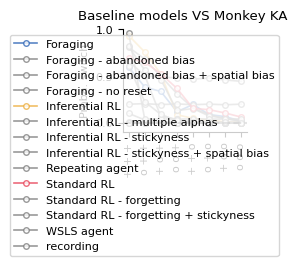

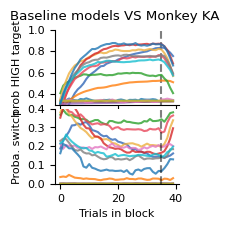

Processing monkey: po
Foraging Foraging - Best target selection: 0.70 ± 0.000000
Foraging - abandoned bias Foraging - abandoned bias - Best target selection: 0.44 ± 0.000000
Foraging - abandoned bias + spatial bias Foraging - abandoned bias + spatial bias - Best target selection: 0.33 ± 0.000000
Foraging - no reset Foraging - no reset - Best target selection: 0.36 ± 0.000000
Inferential RL Inferential RL - Best target selection: 0.40 ± 0.000000
Inferential RL - multiple alphas Inferential RL - multiple alphas - Best target selection: 0.62 ± 0.000000
Inferential RL - stickyness Inferential RL - stickyness - Best target selection: 0.70 ± 0.000000
Inferential RL - stickyness + spatial bias Inferential RL - stickyness + spatial bias - Best target selection: 0.69 ± 0.000000
Repeating agent Repeating agent - Best target selection: 0.33 ± 0.000000
Standard RL Standard RL - Best target selection: 0.50 ± 0.000000
Standard RL - forgetting Standard RL - forgetting - Best target selection: 0.48 ± 

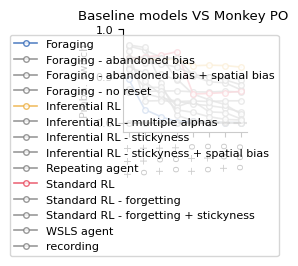

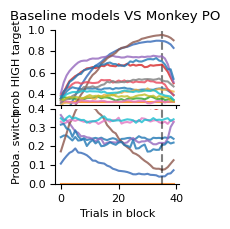

In [3]:
for monkey in ['ka', 'po']:#, 'yu_sham', 'yu_DCZ']:
    print(f'Processing monkey: {monkey}')
    behav = pd.read_pickle(f'results/model_fitting/simulation_behaviors_{monkey}.pkl')

    # Apply the function to create the monkey column
    behav['monkey'] = behav['model']

    behav = convert_column_format(behav, original='simulation')

    behav = add_history_of_feedback(behav, num_trials=3, one_column=False, coding=(0, 1), binary=False)
    behav = add_switch_info(behav, add_trials_since_switch=True, flip_coding=False)
    behav = behav.dropna()

    fig1, _ = plot_hist_thingy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=True)
    # remove legend
    plt.legend([], [], frameon=False)
    fig2, _ = plot_strategy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=True, h=2, w=1.6, ylim=[0, .4], verbose=True)
    # remove legend
    plt.legend([], [], frameon=False)

    # save figs
    fig1.savefig(f'figs/behav_modeling_{monkey}_history_thing.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig1)
    fig2.savefig(f'figs/behav_modeling_{monkey}_strategy.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig2)